In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as pl
import pandas as pd
import seaborn as sb
import marimo as mo

from pathlib import Path

sys.path.insert(0, os.path.abspath("C:\\Users\\rhanes\\GitHub\\tyche\\src"))

import tyche as ty

In [2]:
designs = ty.Designs(
    path = '.',
    name = 'small-modular-reactor.xlsx'
)
investments = ty.Investments(
    path = '.',
    name = 'small-modular-reactor.xlsx'
)

designs.compile()

In [3]:
tranche_results = investments.evaluate_tranches(designs, sample_count=1000).metrics

Evaluating Nuclear SMR


In [4]:
tranche_results.xs(1, level="Sample", drop_level=False)

Value  \
Category             Tranche            Sample Technology  Index                                 
Long Term Planning   BOAK 13 Orders     1      Nuclear SMR Construction Duration  4.802615e+01   
                                                           Levelized Net OCC      3.327072e+03   
                                                           Levelized Net TCI      5.502515e+03   
                                                           Total OCC              1.034054e+09   
Medium Term Planning BOAK 2 of 6 Orders 1      Nuclear SMR Construction Duration  6.703049e+01   
                                                           Levelized Net OCC      6.394958e+03   
                                                           Levelized Net TCI      9.520552e+03   
                                                           Total OCC              1.987553e+09   
Near Term Planning   BOAK 3 Orders      1      Nuclear SMR Construction Duration  5.208287e+01   
                                                           Levelized Net OCC      5.912375e+03   
                                                           Levelized Net TCI      6.926747e+03   
                                                           Total OCC              1.837566e+09   
Medium Term Planning BOAK 3 of 6 Orders 1      Nuclear SMR Construction Duration  5.769328e+01   
                                                           Levelized Net OCC      3.785968e+03   
                                                           Levelized Net TCI      4.877607e+03   
                                                           Total OCC              1.176679e+09   
                     BOAK 4 of 6 Orders 1      Nuclear SMR Construction Duration  4.383782e+01   
                                                           Levelized Net OCC      4.150555e+03   
                                                           Levelized Net TCI      6.288147e+03   
                                                           Total OCC              1.289992e+09   
                     BOAK 5 of 6 Orders 1      Nuclear SMR Construction Duration  3.793315e+01   
                                                           Levelized Net OCC      4.346167e+03   
                                                           Levelized Net TCI      5.764147e+03   
                                                           Total OCC              1.350789e+09   
                     BOAK 6 Orders      1      Nuclear SMR Construction Duration  5.835883e+01   
                                                           Levelized Net OCC      3.529191e+03   
                                                           Levelized Net TCI      4.907560e+03   
                                                           Total OCC              1.096873e+09   
Long Term Planning   FOAK 13 Orders     1      Nuclear SMR Construction Duration  1.038950e+02   
                                                           Levelized Net OCC      1.049431e+04   
                                                           Levelized Net TCI      1.795558e+04   
                                                           Total OCC              3.261632e+09   
Near Term Planning   FOAK 3 Orders      1      Nuclear SMR Construction Duration  8.000465e+01   
                                                           Levelized Net OCC      6.933399e+03   
                                                           Levelized Net TCI      9.839058e+03   
                                                           Total OCC              2.154900e+09   
Medium Term Planning FOAK 6 Orders      1      Nuclear SMR Construction Duration  1.050478e+02   
                                                           Levelized Net OCC      9.721963e+03   
                                                           Levelized Net TCI      1.269493e+04   
                                                           Total OCC   

[Text(0, 0, 'FOAK 6 Orders'),
 Text(1, 0, 'BOAK 2 of 6 Orders'),
 Text(2, 0, 'BOAK 3 of 6 Orders'),
 Text(3, 0, 'BOAK 4 of 6 Orders'),
 Text(4, 0, 'BOAK 5 of 6 Orders'),
 Text(5, 0, 'NOAK 6 Orders')]

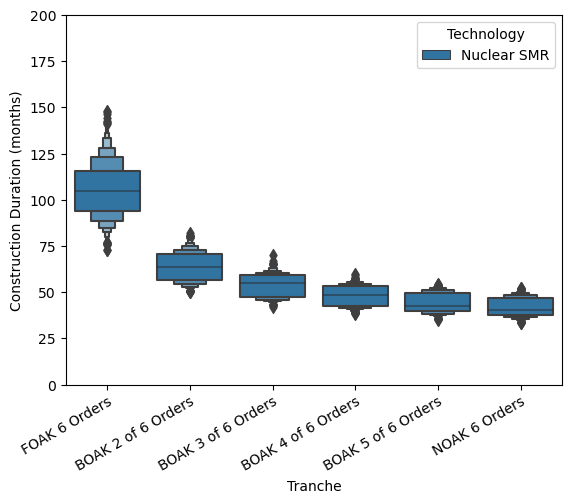

In [5]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Construction Duration",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK 6 Orders",
        "BOAK 2 of 6 Orders",
        "BOAK 3 of 6 Orders",
        "BOAK 4 of 6 Orders",
        "BOAK 5 of 6 Orders",
        "NOAK 6 Orders",
        ]
    )
g.set(ylabel="Construction Duration (months)",
     ylim=(0,200))
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

[Text(0, 0, 'FOAK 3 Orders'),
 Text(1, 0, 'BOAK 3 Orders'),
 Text(2, 0, 'NOAK 3 Orders'),
 Text(3, 0, 'FOAK 6 Orders'),
 Text(4, 0, 'BOAK 6 Orders'),
 Text(5, 0, 'NOAK 6 Orders'),
 Text(6, 0, 'FOAK 13 Orders'),
 Text(7, 0, 'BOAK 13 Orders'),
 Text(8, 0, 'NOAK 13 Orders')]

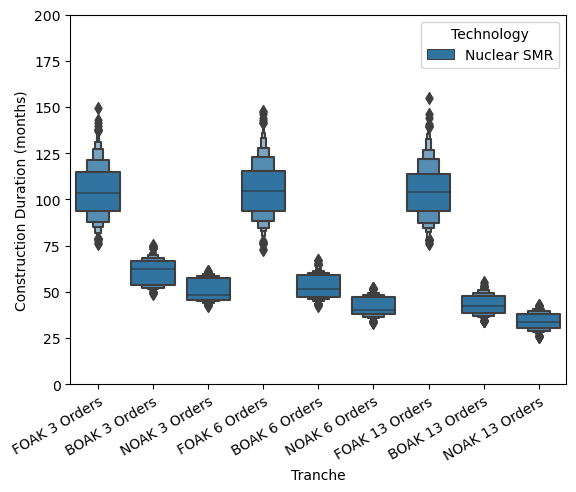

In [6]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Construction Duration",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK 3 Orders",
        "BOAK 3 Orders",
        "NOAK 3 Orders",
        "FOAK 6 Orders",
        "BOAK 6 Orders",
        "NOAK 6 Orders",
        "FOAK 13 Orders",
        "BOAK 13 Orders",
        "NOAK 13 Orders"
        ]
    )
g.set(ylabel="Construction Duration (months)",
     ylim=(0,200))
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

[Text(0, 0, 'FOAK 6 Orders'),
 Text(1, 0, 'BOAK 2 of 6 Orders'),
 Text(2, 0, 'BOAK 3 of 6 Orders'),
 Text(3, 0, 'BOAK 4 of 6 Orders'),
 Text(4, 0, 'BOAK 5 of 6 Orders'),
 Text(5, 0, 'NOAK 6 Orders')]

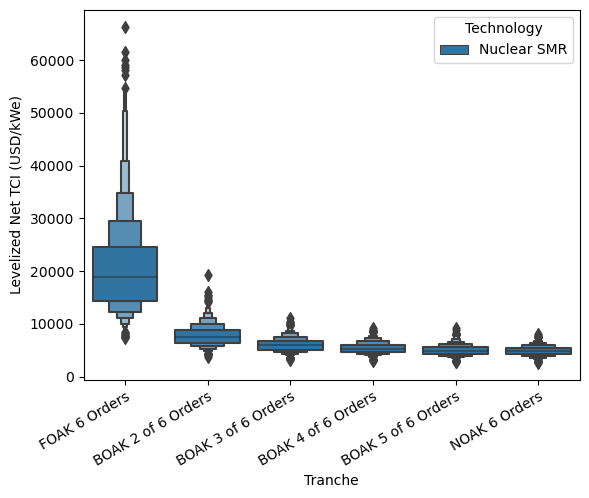

In [10]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Levelized Net TCI",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK 6 Orders",
        "BOAK 2 of 6 Orders",
        "BOAK 3 of 6 Orders",
        "BOAK 4 of 6 Orders",
        "BOAK 5 of 6 Orders",
        "NOAK 6 Orders",
        ]
    )
g.set(ylabel="Levelized Net TCI (USD/kWe)")
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

[Text(0, 0, 'FOAK 3 Orders'),
 Text(1, 0, 'BOAK 3 Orders'),
 Text(2, 0, 'NOAK 3 Orders'),
 Text(3, 0, 'FOAK 6 Orders'),
 Text(4, 0, 'BOAK 6 Orders'),
 Text(5, 0, 'NOAK 6 Orders'),
 Text(6, 0, 'FOAK 13 Orders'),
 Text(7, 0, 'BOAK 13 Orders'),
 Text(8, 0, 'NOAK 13 Orders')]

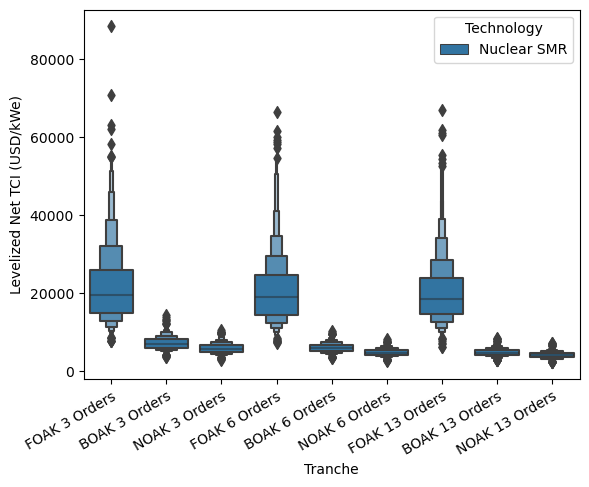

In [7]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Levelized Net TCI",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK 3 Orders",
        "BOAK 3 Orders",
        "NOAK 3 Orders",
        "FOAK 6 Orders",
        "BOAK 6 Orders",
        "NOAK 6 Orders",
        "FOAK 13 Orders",
        "BOAK 13 Orders",
        "NOAK 13 Orders"
        ]
    )
g.set(ylabel="Levelized Net TCI (USD/kWe)")
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

[Text(0, 0, 'FOAK 6 Orders'),
 Text(1, 0, 'BOAK 2 of 6 Orders'),
 Text(2, 0, 'BOAK 3 of 6 Orders'),
 Text(3, 0, 'BOAK 4 of 6 Orders'),
 Text(4, 0, 'BOAK 5 of 6 Orders'),
 Text(5, 0, 'NOAK 6 Orders')]

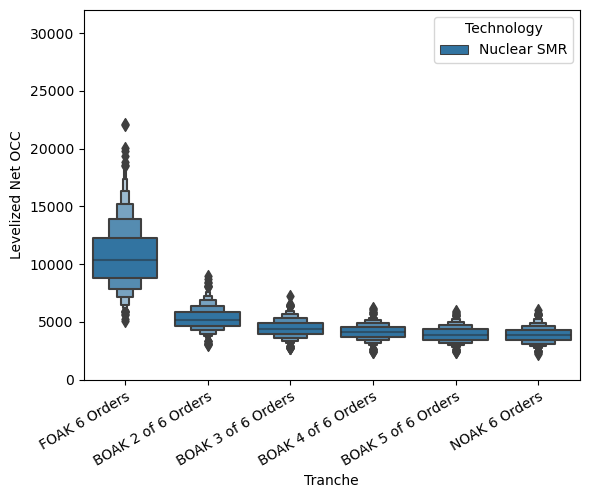

In [11]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Levelized Net OCC",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK 6 Orders",
        "BOAK 2 of 6 Orders",
        "BOAK 3 of 6 Orders",
        "BOAK 4 of 6 Orders",
        "BOAK 5 of 6 Orders",
        "NOAK 6 Orders",
        ]
    )
g.set(ylabel="Levelized Net OCC",
     ylim=(0,32000))
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

[Text(0, 0, 'FOAK 3 Orders'),
 Text(1, 0, 'BOAK 3 Orders'),
 Text(2, 0, 'NOAK 3 Orders'),
 Text(3, 0, 'FOAK 6 Orders'),
 Text(4, 0, 'BOAK 6 Orders'),
 Text(5, 0, 'NOAK 6 Orders'),
 Text(6, 0, 'FOAK 13 Orders'),
 Text(7, 0, 'BOAK 13 Orders'),
 Text(8, 0, 'NOAK 13 Orders')]

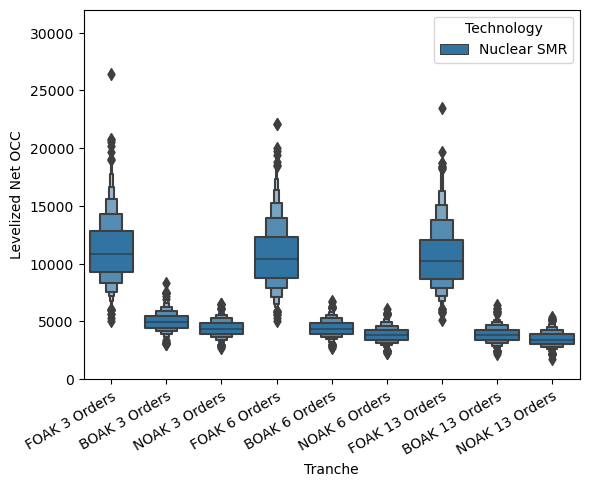

In [8]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Levelized Net OCC",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK 3 Orders",
        "BOAK 3 Orders",
        "NOAK 3 Orders",
        "FOAK 6 Orders",
        "BOAK 6 Orders",
        "NOAK 6 Orders",
        "FOAK 13 Orders",
        "BOAK 13 Orders",
        "NOAK 13 Orders"
        ]
    )
g.set(ylabel="Levelized Net OCC",
     ylim=(0,32000))
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

[Text(0, 0, 'FOAK 6 Orders'),
 Text(1, 0, 'BOAK 2 of 6 Orders'),
 Text(2, 0, 'BOAK 3 of 6 Orders'),
 Text(3, 0, 'BOAK 4 of 6 Orders'),
 Text(4, 0, 'BOAK 5 of 6 Orders'),
 Text(5, 0, 'NOAK 6 Orders')]

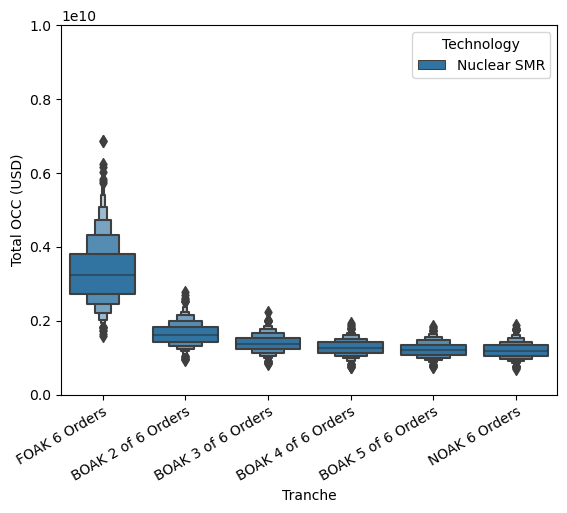

In [12]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Total OCC",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK 6 Orders",
        "BOAK 2 of 6 Orders",
        "BOAK 3 of 6 Orders",
        "BOAK 4 of 6 Orders",
        "BOAK 5 of 6 Orders",
        "NOAK 6 Orders",
        ]
    )
g.set(ylabel="Total OCC (USD)", ylim=(0,1e10))
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

[Text(0, 0, 'FOAK 3 Orders'),
 Text(1, 0, 'BOAK 3 Orders'),
 Text(2, 0, 'NOAK 3 Orders'),
 Text(3, 0, 'FOAK 6 Orders'),
 Text(4, 0, 'BOAK 6 Orders'),
 Text(5, 0, 'NOAK 6 Orders'),
 Text(6, 0, 'FOAK 13 Orders'),
 Text(7, 0, 'BOAK 13 Orders'),
 Text(8, 0, 'NOAK 13 Orders')]

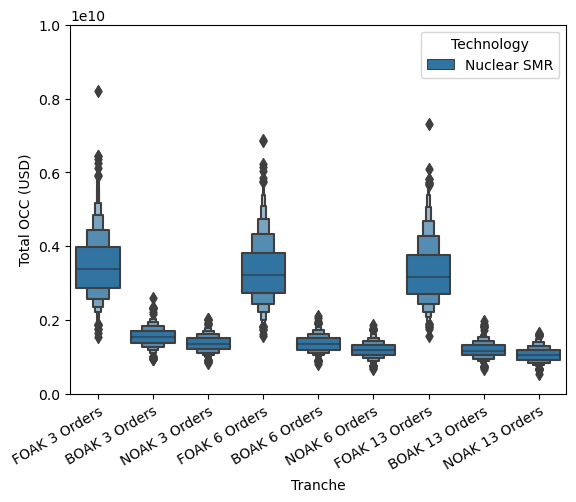

In [9]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Total OCC",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK 3 Orders",
        "BOAK 3 Orders",
        "NOAK 3 Orders",
        "FOAK 6 Orders",
        "BOAK 6 Orders",
        "NOAK 6 Orders",
        "FOAK 13 Orders",
        "BOAK 13 Orders",
        "NOAK 13 Orders"
        ]
    )
g.set(ylabel="Total OCC (USD)", ylim=(0,1e10))
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()